In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import os

In [2]:
gtnet_bin_path = os.path.join(os.environ["SCRATCH"], "exabiome/deep-taxon/gtnet/sota/bins/results.gtnet.npz")
cat_bin_path = os.path.join(os.environ["SCRATCH"], "exabiome/deep-taxon/gtnet/sota/bins/results.cat.npz")
sourmash_bin_path = os.path.join(os.environ["SCRATCH"], "exabiome/deep-taxon/gtnet/sota/bins/results.sourmash.npz")

In [3]:
def read(path):
    results = np.load(path, allow_pickle=True)
    results = {k: results[k] for k in results.keys()}
    results['complete'] = results['complete'].item()
    results['correct'] = results['correct'].item()
    return results

gtnet_results = read(gtnet_bin_path)
cat_results = read(cat_bin_path)
sourmash_results = read(sourmash_bin_path)

In [4]:
gtnet_results['contam_bins'].shape

(22,)

In [5]:
def add_ticks(ax):
    ticks = np.arange(gtnet_results['contam_bins'].shape[0]) - 0.5
    ax.set_yticks(ticks=ticks, labels=gtnet_results['compl_bins']);
    ax.set_xticks(ticks=ticks, labels=gtnet_results['contam_bins'], rotation=90);

In [6]:
def add_labels(axes):
    axes[0].set_ylabel('Completion')
    for ax in axes:
        ax.set_xlabel('Contamination')

def _plot_helper(to_plot, fig=None, axes=None):
    if axes is None and fig is None:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=False)
    else:
        if (axes is None and fig is not None) or (axes is not None and fig is None):
            raise ValueError("You must pass both axes and fig")
    titles = ["GTNet", "CAT", "Sourmash"]
    axes = axes.ravel()

    for i in range(len(to_plot)):
        im = axes[i].imshow(to_plot[i][1:, 1:], cmap='Greys', vmax=1.0, vmin=0.0)
        axes[i].set_title(titles[i])       
        add_ticks(axes[i])
        
    add_labels(axes)
    return fig, axes, im


def _add_cbar(im, fig, axes, label):
    fig.subplots_adjust(right=0.81)
    bbox = axes[-1].get_position()
    cbar_ax = fig.add_axes([0.85, bbox.y0, 0.02, bbox.height])
    fig.colorbar(im, cax=cbar_ax)
    cbar_ax.set_ylabel(label)

    
def plot_complete(tax_level, fig=None, axes=None, title=True):
    to_plot = [
        gtnet_results['complete'][tax_level] / gtnet_results['total'],
        cat_results['complete'][tax_level] / cat_results['total'],
        sourmash_results['complete'][tax_level] / sourmash_results['total']
    ]

    fig, axes, im = _plot_helper(to_plot, fig, axes)
    if title:
        fig.suptitle(f"{tax_level} classification rate by genome quality", fontsize=16)
        
    _add_cbar(im, fig, axes, "Classification rate")
    return fig

        
def plot_correct(tax_level, fig=None, axes=None, title=True):
    to_plot = [
        gtnet_results['correct'][tax_level] / gtnet_results['complete'][tax_level],
        cat_results['correct'][tax_level] / cat_results['complete'][tax_level],
        sourmash_results['correct'][tax_level] / sourmash_results['complete'][tax_level]
    ]
    fig, axes, im = _plot_helper(to_plot, fig, axes)
    if title:
        fig.suptitle(f"{tax_level} accuracy by genome quality", fontsize=16)

    _add_cbar(im, fig, axes, "Accuracy")
    return fig

def plot_total():
    to_plot = np.log10(gtnet_results['total'])

    mx = to_plot.max()
    mn = 0
    
    im = plt.imshow(to_plot[1:, 1:], cmap='Greys', vmin=mn, vmax=mx)
    add_ticks(plt.gca())
    cbar = plt.gcf().colorbar(im)
    pos = [0, 1, 2, 3, 4, 5]
    cbar.set_ticklabels(ticklabels=[f"$10^{_}$" for _ in pos])
    cbar.set_label("Number of genomes")
    add_labels([plt.gca()])
    plt.title("Number of genomes by genome quality")
    

/tmp/ipykernel_472197/3091973353.py:34: RuntimeWarning: invalid value encountered in divide
  gtnet_results['complete'][tax_level] / gtnet_results['total'],
/tmp/ipykernel_472197/3091973353.py:35: RuntimeWarning: invalid value encountered in divide
  cat_results['complete'][tax_level] / cat_results['total'],
/tmp/ipykernel_472197/3091973353.py:36: RuntimeWarning: invalid value encountered in divide
  sourmash_results['complete'][tax_level] / sourmash_results['total']


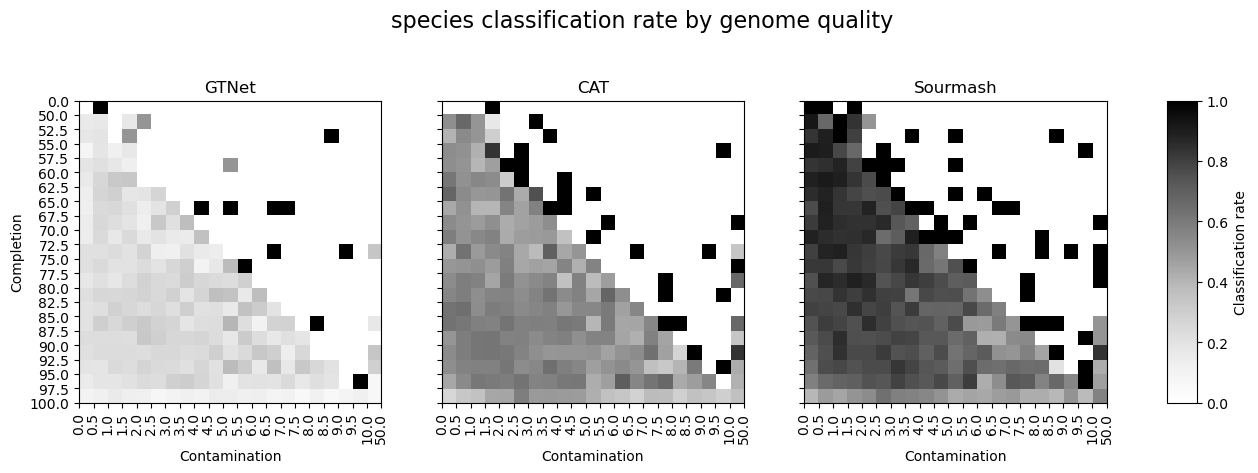

In [7]:
plot_complete('species')
plt.savefig("PlotPredPerf/bins_species_clf_rate.png", dpi=100)

/tmp/ipykernel_472197/3091973353.py:61: RuntimeWarning: divide by zero encountered in log10
  to_plot = np.log10(gtnet_results['total'])
/tmp/ipykernel_472197/3091973353.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels(ticklabels=[f"$10^{_}$" for _ in pos])


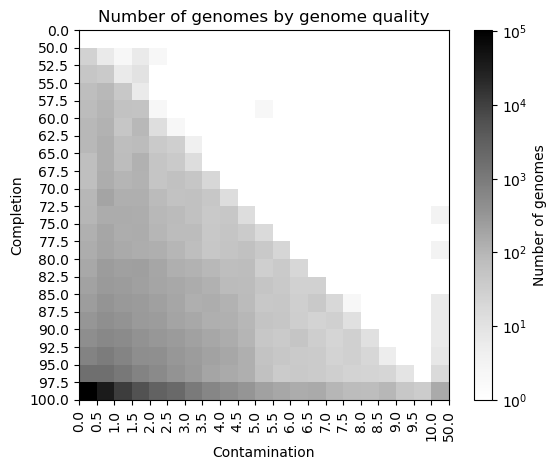

In [8]:
plot_total()
plt.savefig("PlotPredPerf/bins_total_genomes.png")

/tmp/ipykernel_472197/3091973353.py:49: RuntimeWarning: invalid value encountered in divide
  gtnet_results['correct'][tax_level] / gtnet_results['complete'][tax_level],
/tmp/ipykernel_472197/3091973353.py:50: RuntimeWarning: invalid value encountered in divide
  cat_results['correct'][tax_level] / cat_results['complete'][tax_level],
/tmp/ipykernel_472197/3091973353.py:51: RuntimeWarning: invalid value encountered in divide
  sourmash_results['correct'][tax_level] / sourmash_results['complete'][tax_level]


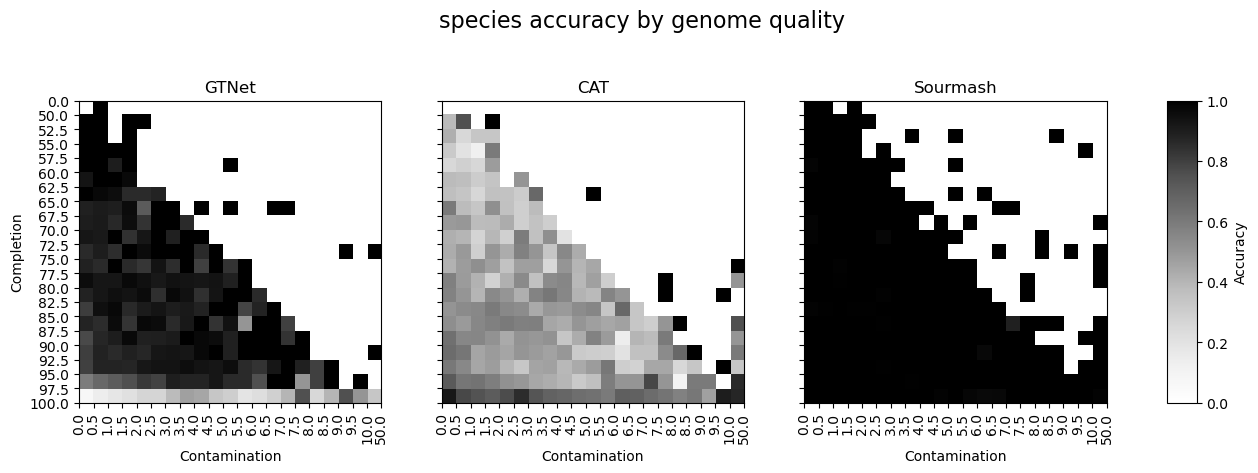

In [9]:
plot_correct('species')
plt.savefig("PlotPredPerf/bins_species_accuracy.png", dpi=100)

/tmp/ipykernel_472197/3091973353.py:34: RuntimeWarning: invalid value encountered in divide
  gtnet_results['complete'][tax_level] / gtnet_results['total'],
/tmp/ipykernel_472197/3091973353.py:35: RuntimeWarning: invalid value encountered in divide
  cat_results['complete'][tax_level] / cat_results['total'],
/tmp/ipykernel_472197/3091973353.py:36: RuntimeWarning: invalid value encountered in divide
  sourmash_results['complete'][tax_level] / sourmash_results['total']


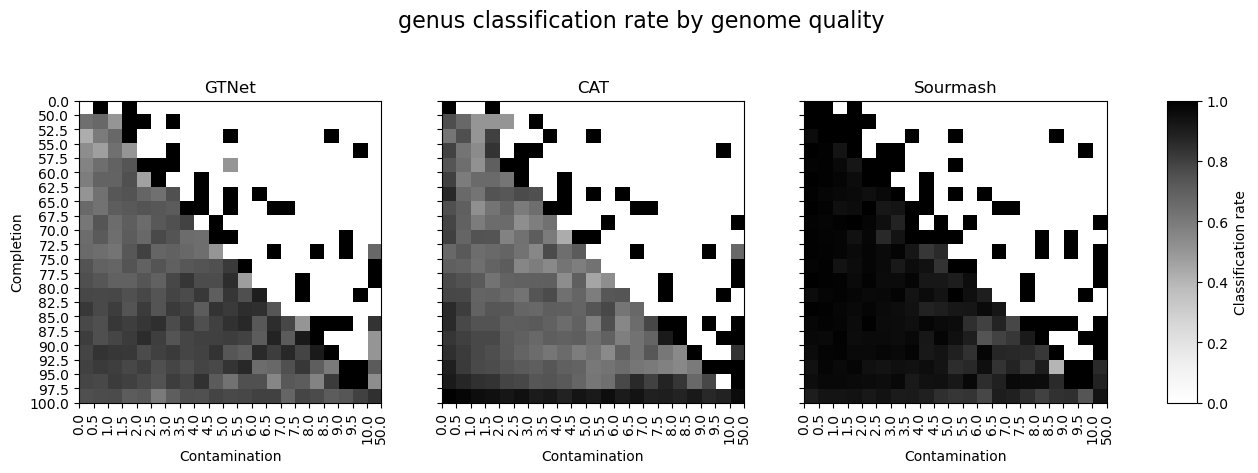

In [10]:
plot_complete('genus')
plt.savefig("PlotPredPerf/bins_genus_clf_rate.png", dpi=100)

/tmp/ipykernel_472197/3091973353.py:49: RuntimeWarning: invalid value encountered in divide
  gtnet_results['correct'][tax_level] / gtnet_results['complete'][tax_level],
/tmp/ipykernel_472197/3091973353.py:50: RuntimeWarning: invalid value encountered in divide
  cat_results['correct'][tax_level] / cat_results['complete'][tax_level],
/tmp/ipykernel_472197/3091973353.py:51: RuntimeWarning: invalid value encountered in divide
  sourmash_results['correct'][tax_level] / sourmash_results['complete'][tax_level]


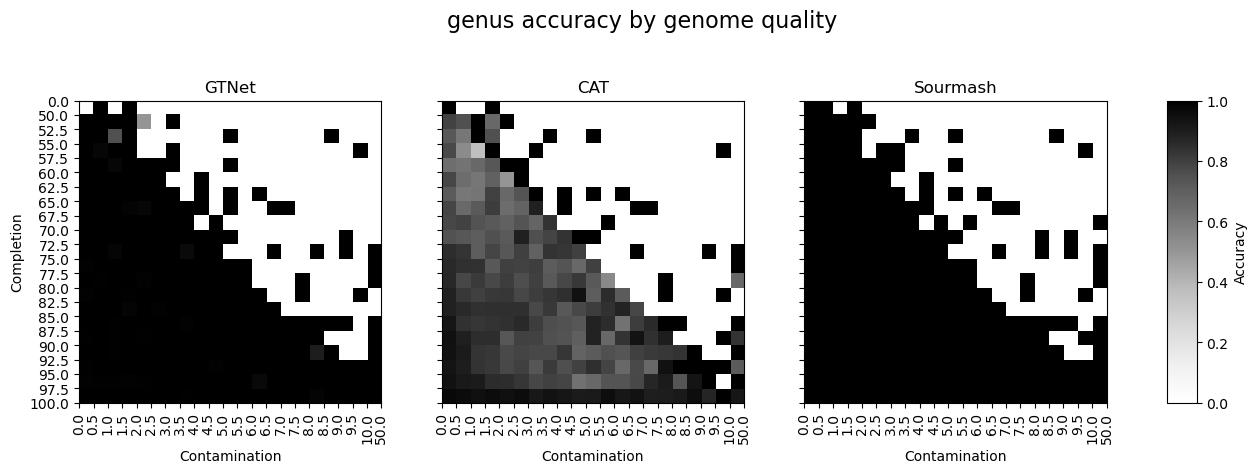

In [11]:
plot_correct('genus')
plt.savefig("PlotPredPerf/bins_genus_accuracy.png", dpi=100)

/tmp/ipykernel_472197/3091973353.py:49: RuntimeWarning: invalid value encountered in divide
  gtnet_results['correct'][tax_level] / gtnet_results['complete'][tax_level],
/tmp/ipykernel_472197/3091973353.py:50: RuntimeWarning: invalid value encountered in divide
  cat_results['correct'][tax_level] / cat_results['complete'][tax_level],
/tmp/ipykernel_472197/3091973353.py:51: RuntimeWarning: invalid value encountered in divide
  sourmash_results['correct'][tax_level] / sourmash_results['complete'][tax_level]
/tmp/ipykernel_472197/3091973353.py:49: RuntimeWarning: invalid value encountered in divide
  gtnet_results['correct'][tax_level] / gtnet_results['complete'][tax_level],
/tmp/ipykernel_472197/3091973353.py:50: RuntimeWarning: invalid value encountered in divide
  cat_results['correct'][tax_level] / cat_results['complete'][tax_level],
/tmp/ipykernel_472197/3091973353.py:51: RuntimeWarning: invalid value encountered in divide
  sourmash_results['correct'][tax_level] / sourmash_results['

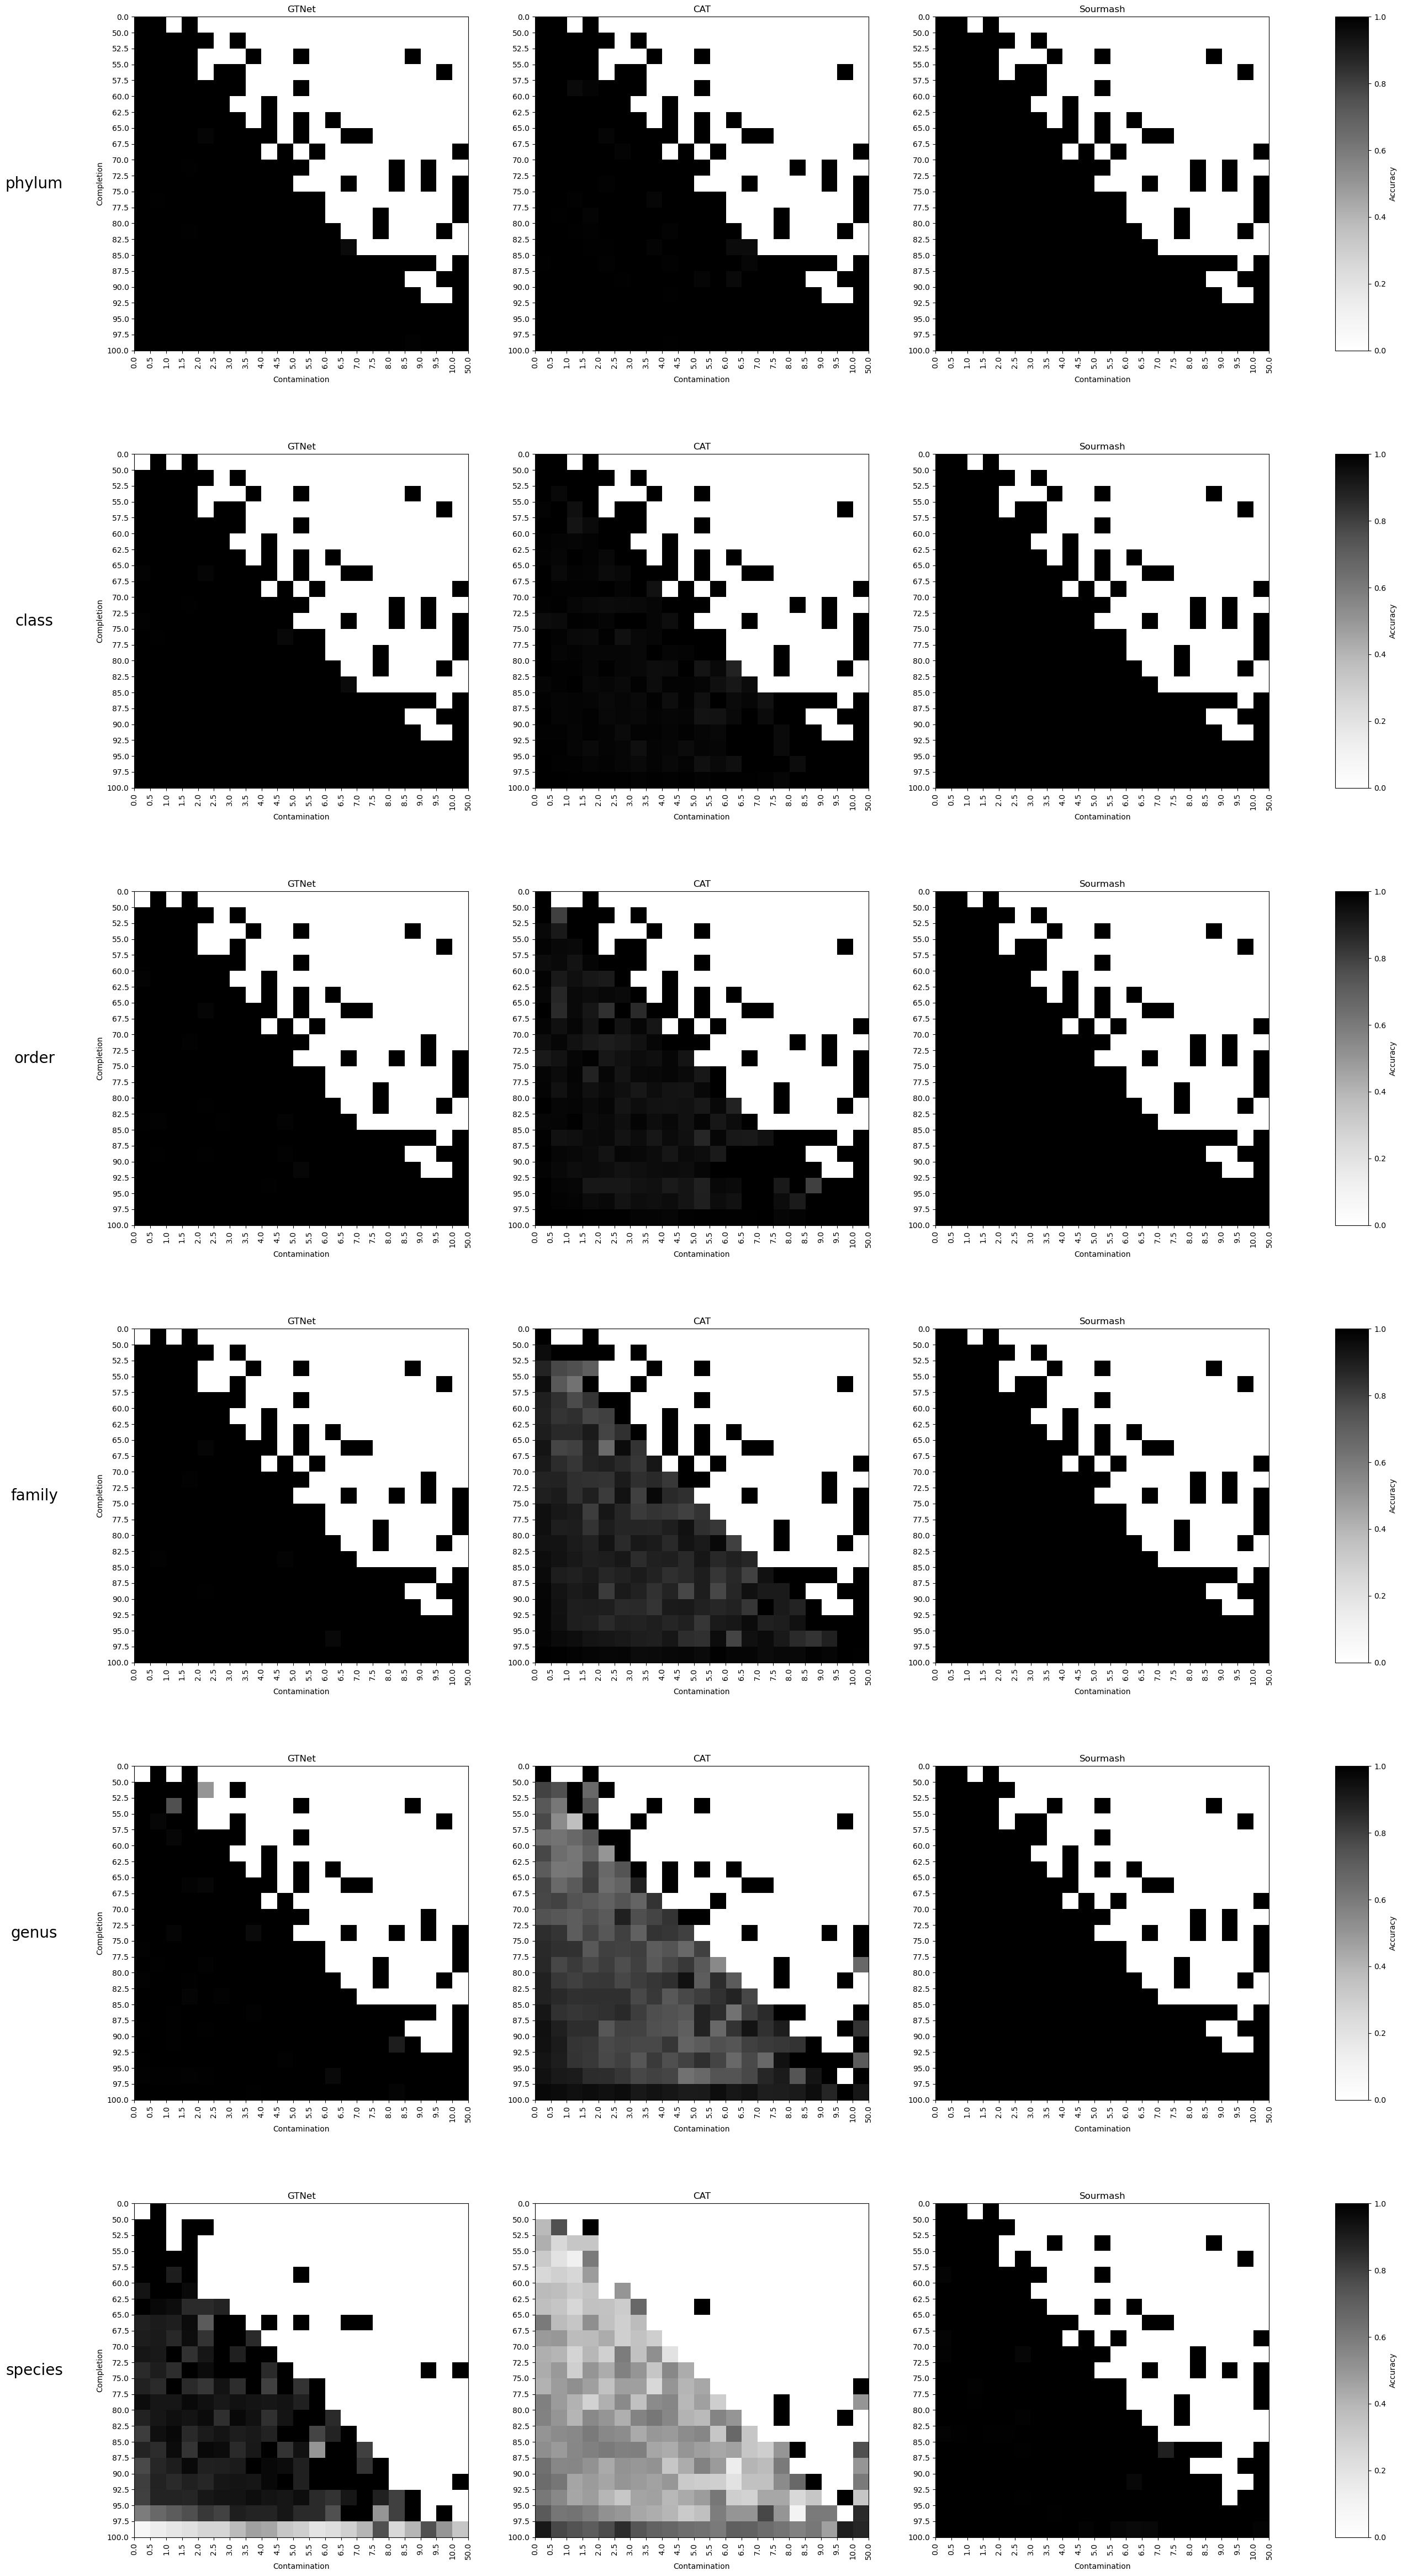

In [12]:
fig, axes = plt.subplots(6, 3, figsize=(30, 60))
for i, lvl in enumerate(['phylum', 'class', 'order', 'family', 'genus', 'species']):
    _axes = axes[i]
    ax = _axes[0]
    fig = plot_correct(lvl, title=False, axes=_axes, fig=fig)
    ax.text(-0.3, 0.5, lvl, 
        ha='center', va='center', rotation='horizontal', transform=ax.transAxes, fontsize=20)
plt.savefig("PlotPredPerf/bins_all_accuracy.png", dpi=100)

/tmp/ipykernel_472197/3091973353.py:34: RuntimeWarning: invalid value encountered in divide
  gtnet_results['complete'][tax_level] / gtnet_results['total'],
/tmp/ipykernel_472197/3091973353.py:35: RuntimeWarning: invalid value encountered in divide
  cat_results['complete'][tax_level] / cat_results['total'],
/tmp/ipykernel_472197/3091973353.py:36: RuntimeWarning: invalid value encountered in divide
  sourmash_results['complete'][tax_level] / sourmash_results['total']
/tmp/ipykernel_472197/3091973353.py:34: RuntimeWarning: invalid value encountered in divide
  gtnet_results['complete'][tax_level] / gtnet_results['total'],
/tmp/ipykernel_472197/3091973353.py:35: RuntimeWarning: invalid value encountered in divide
  cat_results['complete'][tax_level] / cat_results['total'],
/tmp/ipykernel_472197/3091973353.py:36: RuntimeWarning: invalid value encountered in divide
  sourmash_results['complete'][tax_level] / sourmash_results['total']
/tmp/ipykernel_472197/3091973353.py:34: RuntimeWarning: 

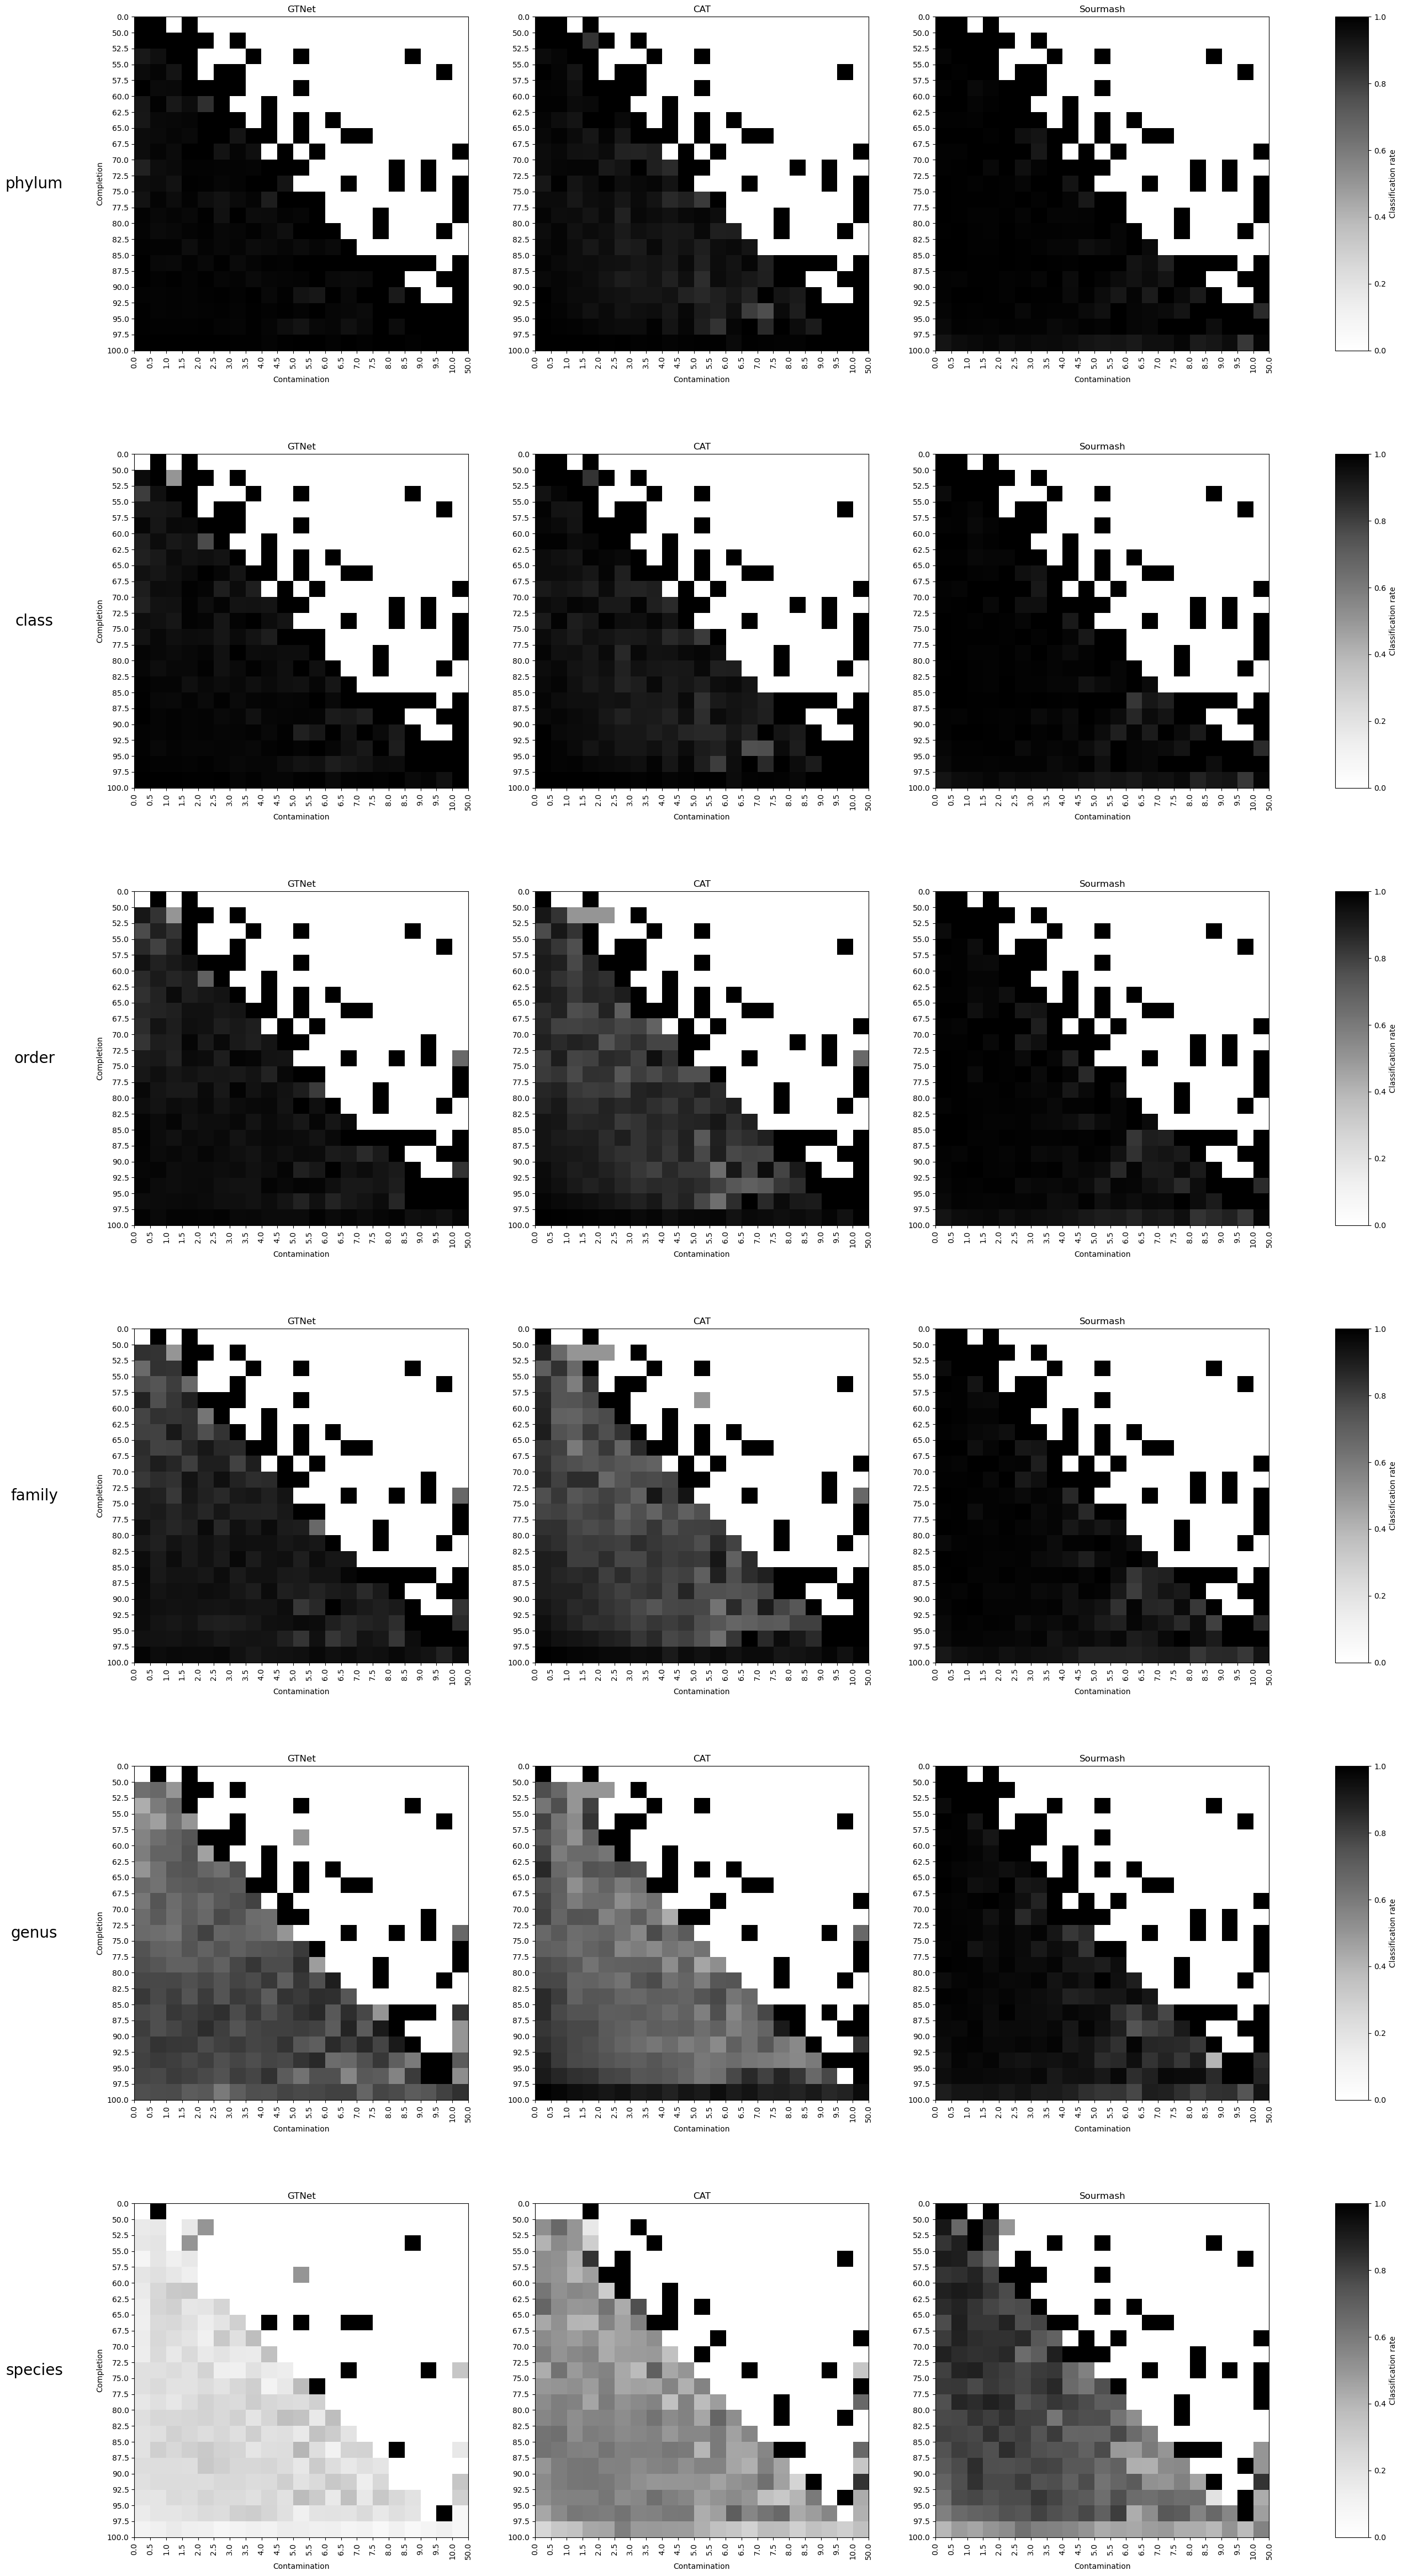

In [13]:
fig, axes = plt.subplots(6, 3, figsize=(30, 60))
for i, lvl in enumerate(['phylum', 'class', 'order', 'family', 'genus', 'species']):
    _axes = axes[i]
    ax = _axes[0]
    fig = plot_complete(lvl, title=False, axes=_axes, fig=fig)
    ax.text(-0.3, 0.5, lvl, 
        ha='center', va='center', rotation='horizontal', transform=ax.transAxes, fontsize=20)
plt.savefig("PlotPredPerf/bins_all_clf_rate.png", dpi=100)